In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_recall_curve
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [2]:
#load dataset
mush_data=pd.read_csv('mushrooms.csv')
iris_data=pd.read_csv('Iris.csv')

In [3]:
mush_data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
iris_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
#Apply Label Encoder on both Data set
le=LabelEncoder()
for i in mush_data.columns:
    mush_data[i]=le.fit_transform(mush_data[i])
for i in iris_data.columns:
    iris_data[i]=le.fit_transform(iris_data[i])

In [6]:
mush_data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [7]:
iris_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,0,8,14,4,1,0
1,1,6,9,4,1,0
2,2,4,11,3,1,0
3,3,3,10,5,1,0
4,4,7,15,4,1,0


In [8]:
#split data into x and y
x_mush=mush_data.drop('class',axis=1)
y_mush=mush_data['class']
x_iris=iris_data.drop('Species',axis=1)
y_iris=iris_data['Species']

In [9]:
#split data into train and test
x_mush_train,x_mush_test,y_mush_train,y_mush_test=train_test_split(x_mush,y_mush,test_size=0.2,random_state=42)
x_iris_train,x_iris_test,y_iris_train,y_iris_test=train_test_split(x_iris,y_iris,test_size=0.2,random_state=42)

In [10]:
def model(x_train,x_test,y_train,y_test,models):
    models.fit(x_train,y_train)
    y_pred=models.predict(x_test)
    y_pred_prob = models.predict_proba(x_test)[:, 1] if hasattr(models, "predict_proba") else models.decision_function(x_test)
    print(accuracy_score(y_test,y_pred)*100)
    print(confusion_matrix(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    print(f1_score(y_test,y_pred))
    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
    plt.show()
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, lw=2, color='b')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {type(models).__name__}')
    plt.show()

Press 1:Mushroom Dataset
Press 2:Iris Dataset
Enter your choice:1
1.Logistic Regression
2.Random Forest Classifier
3.Decision Tree Classifier
4.KNN Classifier
5.SVM Classifier
6.Naive Bayes Classifier
8.Exit
Enter your choice:1
94.76923076923077
[[799  44]
 [ 41 741]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       843
           1       0.94      0.95      0.95       782

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

0.9457562220804084


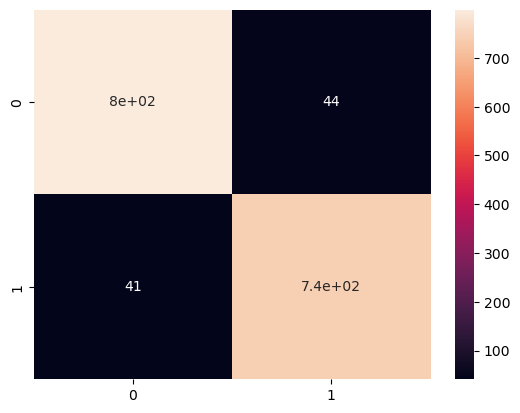

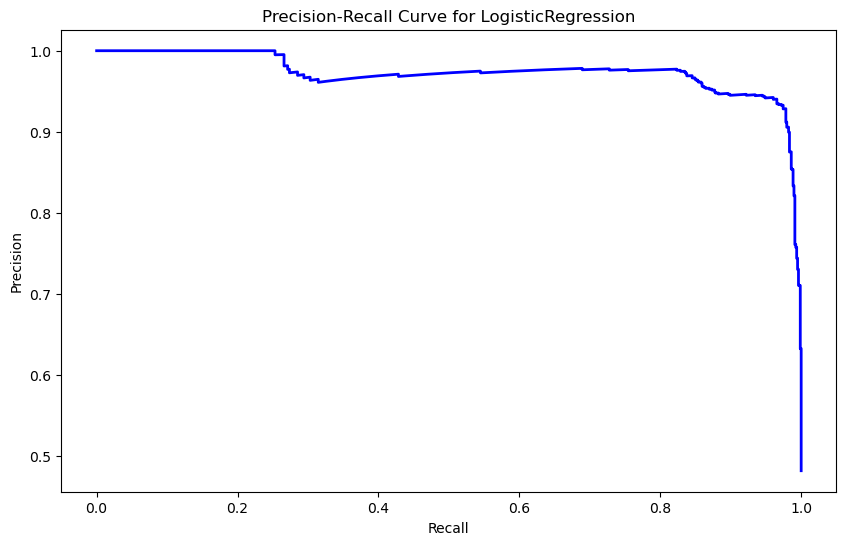

1.Logistic Regression
2.Random Forest Classifier
3.Decision Tree Classifier
4.KNN Classifier
5.SVM Classifier
6.Naive Bayes Classifier
8.Exit
Enter your choice:2
99.07692307692308
[[843   0]
 [ 15 767]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       843
           1       1.00      0.98      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625

0.9903163331181407


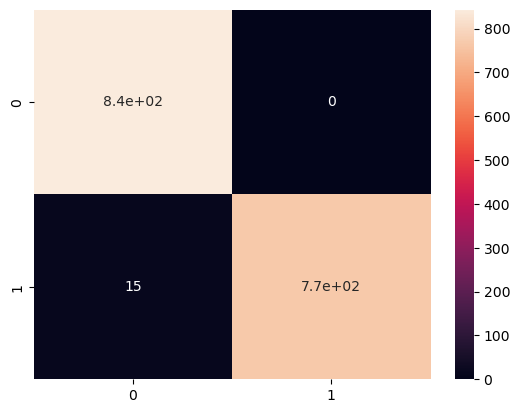

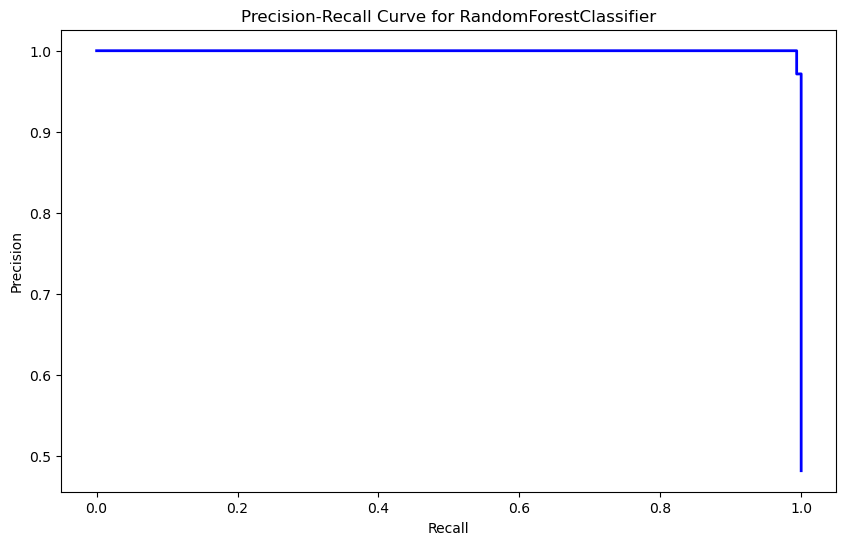

1.Logistic Regression
2.Random Forest Classifier
3.Decision Tree Classifier
4.KNN Classifier
5.SVM Classifier
6.Naive Bayes Classifier
8.Exit
Enter your choice:3
97.66153846153847
[[814  29]
 [  9 773]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       843
           1       0.96      0.99      0.98       782

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625

0.976010101010101


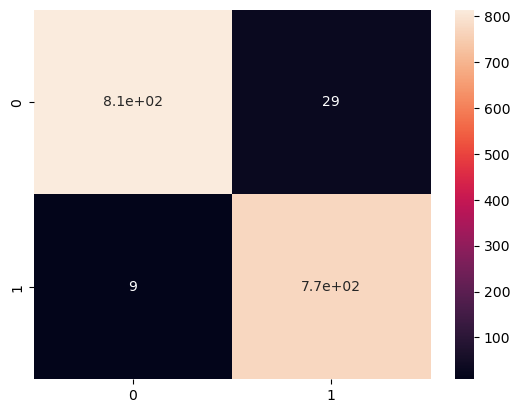

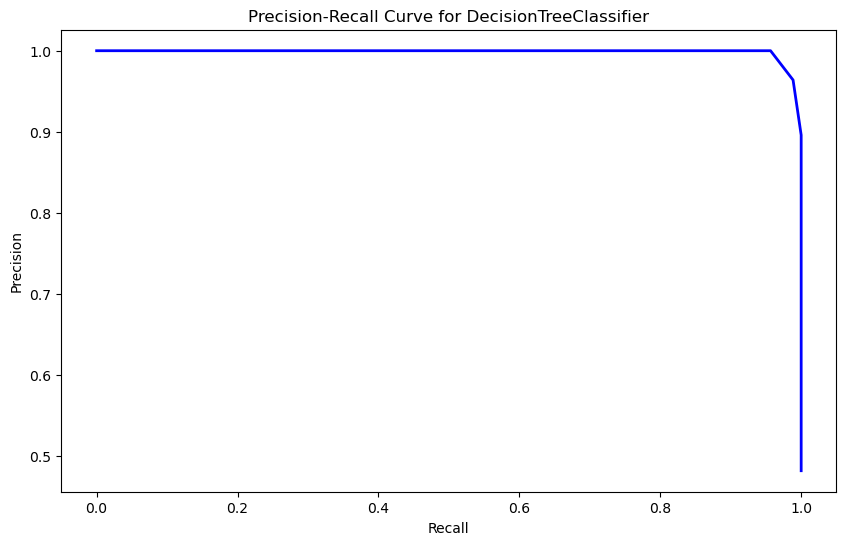

1.Logistic Regression
2.Random Forest Classifier
3.Decision Tree Classifier
4.KNN Classifier
5.SVM Classifier
6.Naive Bayes Classifier
8.Exit
Enter your choice:4
99.63076923076923
[[837   6]
 [  0 782]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       843
           1       0.99      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

0.9961783439490446


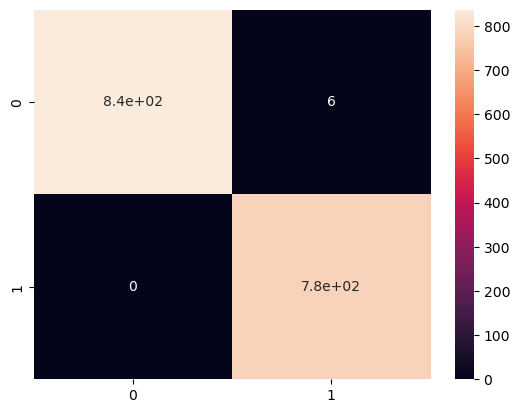

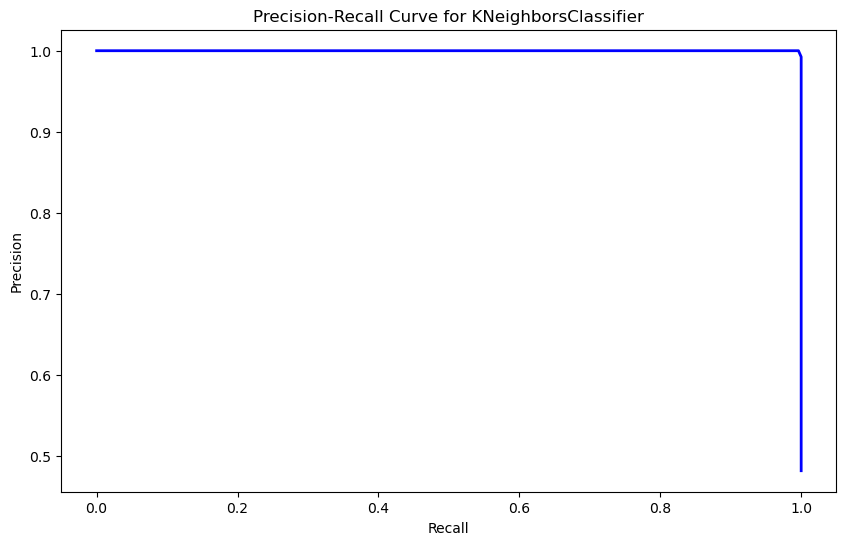

1.Logistic Regression
2.Random Forest Classifier
3.Decision Tree Classifier
4.KNN Classifier
5.SVM Classifier
6.Naive Bayes Classifier
8.Exit
Enter your choice:5


C:\Users\Ahmad Yasin\anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


62.4
[[513 330]
 [281 501]]
              precision    recall  f1-score   support

           0       0.65      0.61      0.63       843
           1       0.60      0.64      0.62       782

    accuracy                           0.62      1625
   macro avg       0.62      0.62      0.62      1625
weighted avg       0.63      0.62      0.62      1625

0.6212027278363298


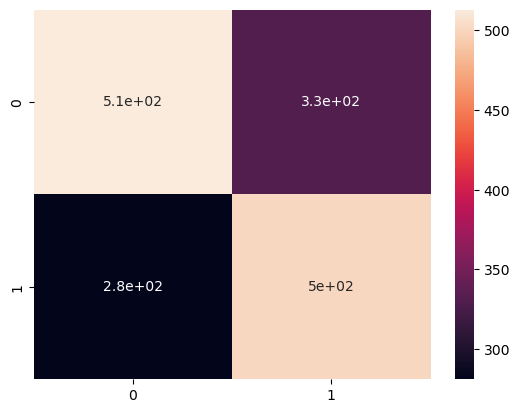

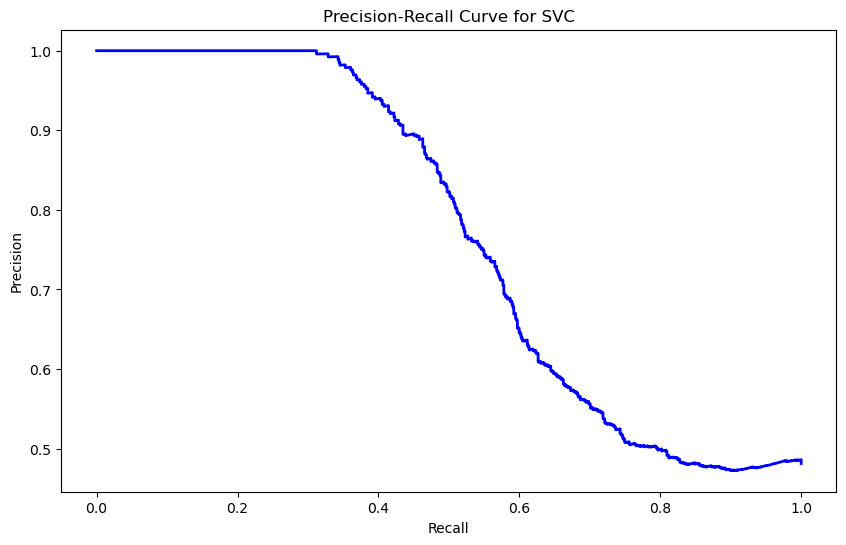

1.Logistic Regression
2.Random Forest Classifier
3.Decision Tree Classifier
4.KNN Classifier
5.SVM Classifier
6.Naive Bayes Classifier
8.Exit
Enter your choice:6
92.18461538461538
[[771  72]
 [ 55 727]]
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       843
           1       0.91      0.93      0.92       782

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625

0.9196710942441493


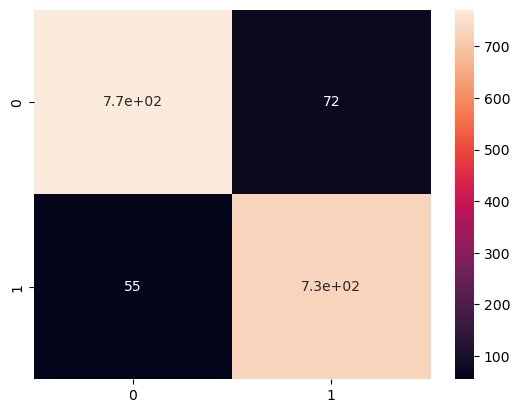

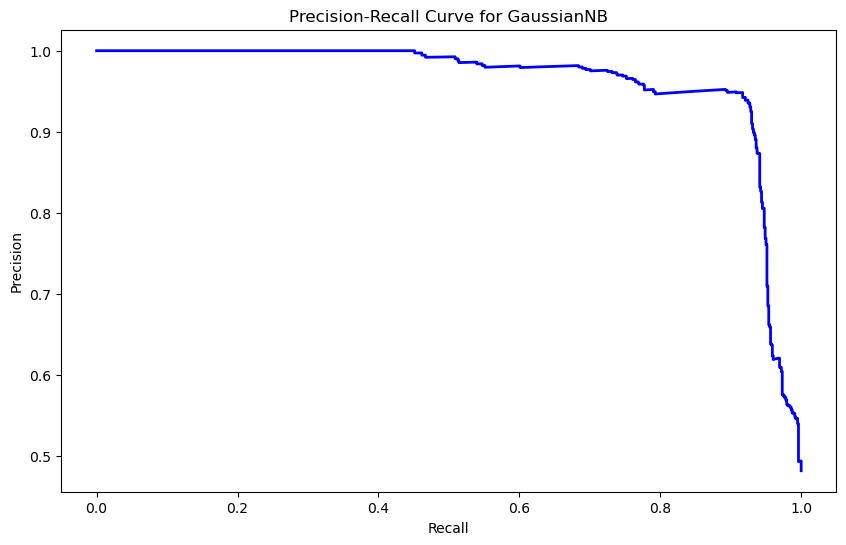

1.Logistic Regression
2.Random Forest Classifier
3.Decision Tree Classifier
4.KNN Classifier
5.SVM Classifier
6.Naive Bayes Classifier
8.Exit
Enter your choice:8


In [11]:
models=[RandomForestClassifier(),LogisticRegression(),DecisionTreeClassifier(),KNeighborsClassifier(),SVC(),GaussianNB()]
#int main
if __name__=="__main__":
    print('Press 1:Mushroom Dataset')
    print('Press 2:Iris Dataset')
    choice=int(input('Enter your choice:'))
    if choice==1:
        while(True):
            print("1.Logistic Regression")
            print("2.Random Forest Classifier")
            print("3.Decision Tree Classifier")
            print("4.KNN Classifier")
            print("5.SVM Classifier")
            print("6.Naive Bayes Classifier")
            print("7.Exit")
            choice=int(input("Enter your choice:"))
            if choice==1:
                model(x_mush_train,x_mush_test,y_mush_train,y_mush_test,LogisticRegression(max_iter=1000))
            elif choice==2:
                model(x_mush_train,x_mush_test,y_mush_train,y_mush_test,RandomForestClassifier(max_depth=5))
            elif choice==3:
                model(x_mush_train,x_mush_test,y_mush_train,y_mush_test,DecisionTreeClassifier(max_depth=5))
            elif choice==4:
                model(x_mush_train,x_mush_test,y_mush_train,y_mush_test,KNeighborsClassifier(n_neighbors=5))
            elif choice==5:
                model(x_mush_train,x_mush_test,y_mush_train,y_mush_test,SVC(max_iter=100))
            elif choice==6:
                model(x_mush_train,x_mush_test,y_mush_train,y_mush_test,GaussianNB())
            elif choice==7:
                break
            else:
                print("Invalid Choice")
    elif choice==2:
         while(True):
            print("1.Logistic Regression")
            print("2.Random Forest Classifier")
            print("3.Decision Tree Classifier")
            print("4.KNN Classifier")
            print("5.SVM Classifier")
            print("6.Naive Bayes Classifier")
            print("7.Exit")
            choice=int(input("Enter your choice:"))
            if choice==1:
                model(x_iris_train,x_iris_test,y_iris_train,y_iris_test,LogisticRegression(max_iter=1000))
            elif choice==2:
                model(x_iris_train,x_iris_test,y_iris_train,y_iris_test,RandomForestClassifier(max_depth=5))
            elif choice==3:
                model(x_iris_train,x_iris_test,y_iris_train,y_iris_test,DecisionTreeClassifier(max_depth=5))
            elif choice==4:
                model(x_iris_train,x_iris_test,y_iris_train,y_iris_test,KNeighborsClassifier(n_neighbors=5))
            elif choice==5:
                model(x_iris_train,x_iris_test,y_iris_train,y_iris_test,SVC(max_iter=100))
            elif choice==6:
                model(x_iris_train,x_iris_test,y_iris_train,y_iris_test,GaussianNB())
            elif choice==7:
                break
            else:
                print("Invalid Choice")
    else:
        print('Invalid Choice')